# AR Segmentation — results viewer

Displays the outputs of the inference / averaging / false-colour pipeline.
Runs on the default `python3` kernel — no torch, no GPU, it only reads files.

| produced by | what | where |
|---|---|---|
| `infer_file.py` | per-channel prediction panels + NetCDF, one dir per checkpoint | `~/infer_run1`, `~/infer_run2`, `~/infer_run3` |
| `average_masks.py` | pixelwise mean mask across those runs | `~/infer_mask_mean` |
| `false_color.py` | false-colour JPEG of the mean mask | `~/infer_false_color_aia94` |

Everything is 4096x4096, so each display downsamples. **Sparse mask images use
block-max, not averaging** — averaging dissolves features covering <1% of the
frame into the background and they vanish from the preview.

In [1]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from PIL import Image

Image.MAX_IMAGE_PIXELS = None  # these are 4096x4096, above PIL's default guard

RUN_DIRS = {
    "run1 - released weights": "~/infer_run1",
    "run2 - feb16 epoch_9": "~/infer_run2",
    "run3 - feb17 epoch_9": "~/infer_run3",
}
MEAN_DIR = "~/infer_mask_mean"
FALSE_COLOR_DIR = "~/infer_false_color_aia94"

CHANNEL = "aia94"  # change and re-run the cells below

expand = os.path.expanduser
for label, d in list(RUN_DIRS.items()) + [("mean", MEAN_DIR), ("false colour", FALSE_COLOR_DIR)]:
    path = expand(d)
    n = len(glob.glob(os.path.join(path, "*"))) if os.path.isdir(path) else 0
    print(f"{'OK ' if n else 'MISSING'}  {label:<26} {d}  ({n} files)")

OK   run1 - released weights    ~/infer_run1  (16 files)
OK   run2 - feb16 epoch_9       ~/infer_run2  (16 files)
OK   run3 - feb17 epoch_9       ~/infer_run3  (16 files)
OK   mean                       ~/infer_mask_mean  (16 files)
OK   false colour               ~/infer_false_color_aia94  (2 files)


## Helpers

In [2]:
def block_max(img, factor):
    """Downsample by taking the max over each factor x factor block.

    Averaging would erase sparse features; max keeps any coloured pixel visible.
    """
    h, w = img.shape[:2]
    h, w = h - h % factor, w - w % factor  # crop to a multiple of factor
    img = img[:h, :w]
    if img.ndim == 3:
        return img.reshape(h // factor, factor, w // factor, factor, img.shape[2]).max(axis=(1, 3))
    return img.reshape(h // factor, factor, w // factor, factor).max(axis=(1, 3))


def load_preview(path, max_px=1000, sparse=False):
    """Read an image file and shrink it for inline display."""
    img = np.asarray(Image.open(path))
    factor = max(1, int(np.ceil(max(img.shape[:2]) / max_px)))
    if factor == 1:
        return img
    if sparse:
        return block_max(img, factor)
    return np.asarray(Image.fromarray(img).resize(
        (img.shape[1] // factor, img.shape[0] // factor), Image.LANCZOS))


def show(items, ncols=1, height=6, sparse=False):
    """Display (title, path) pairs in a grid."""
    items = [it for it in items if os.path.exists(it[1])]
    if not items:
        print("Nothing to show - are the result directories present?")
        return
    previews = [(title, load_preview(path, sparse=sparse)) for title, path in items]
    # Size the figure from the images' own aspect ratio; a fixed guess leaves
    # large dead bands between rows, since the 3-panel PNGs are much wider
    # than the square false-colour frames.
    h, w = previews[0][1].shape[:2]
    aspect = w / h
    nrows = int(np.ceil(len(previews) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(ncols * height * aspect, nrows * height)
    )
    axes = np.atleast_1d(axes).ravel()
    for ax, (title, img) in zip(axes, previews):
        ax.imshow(img)
        ax.set_title(title, fontsize=11)
        ax.axis("off")
    for ax in axes[len(previews):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def find(directory, pattern):
    hits = sorted(glob.glob(os.path.join(expand(directory), pattern)))
    return hits[0] if hits else ""

## 1. Prediction from each checkpoint

Three panels per run: the channel image, the predicted AR probability, and the
thresholded mask overlaid. Same input file and channel throughout, so the only
thing differing between rows is the checkpoint.

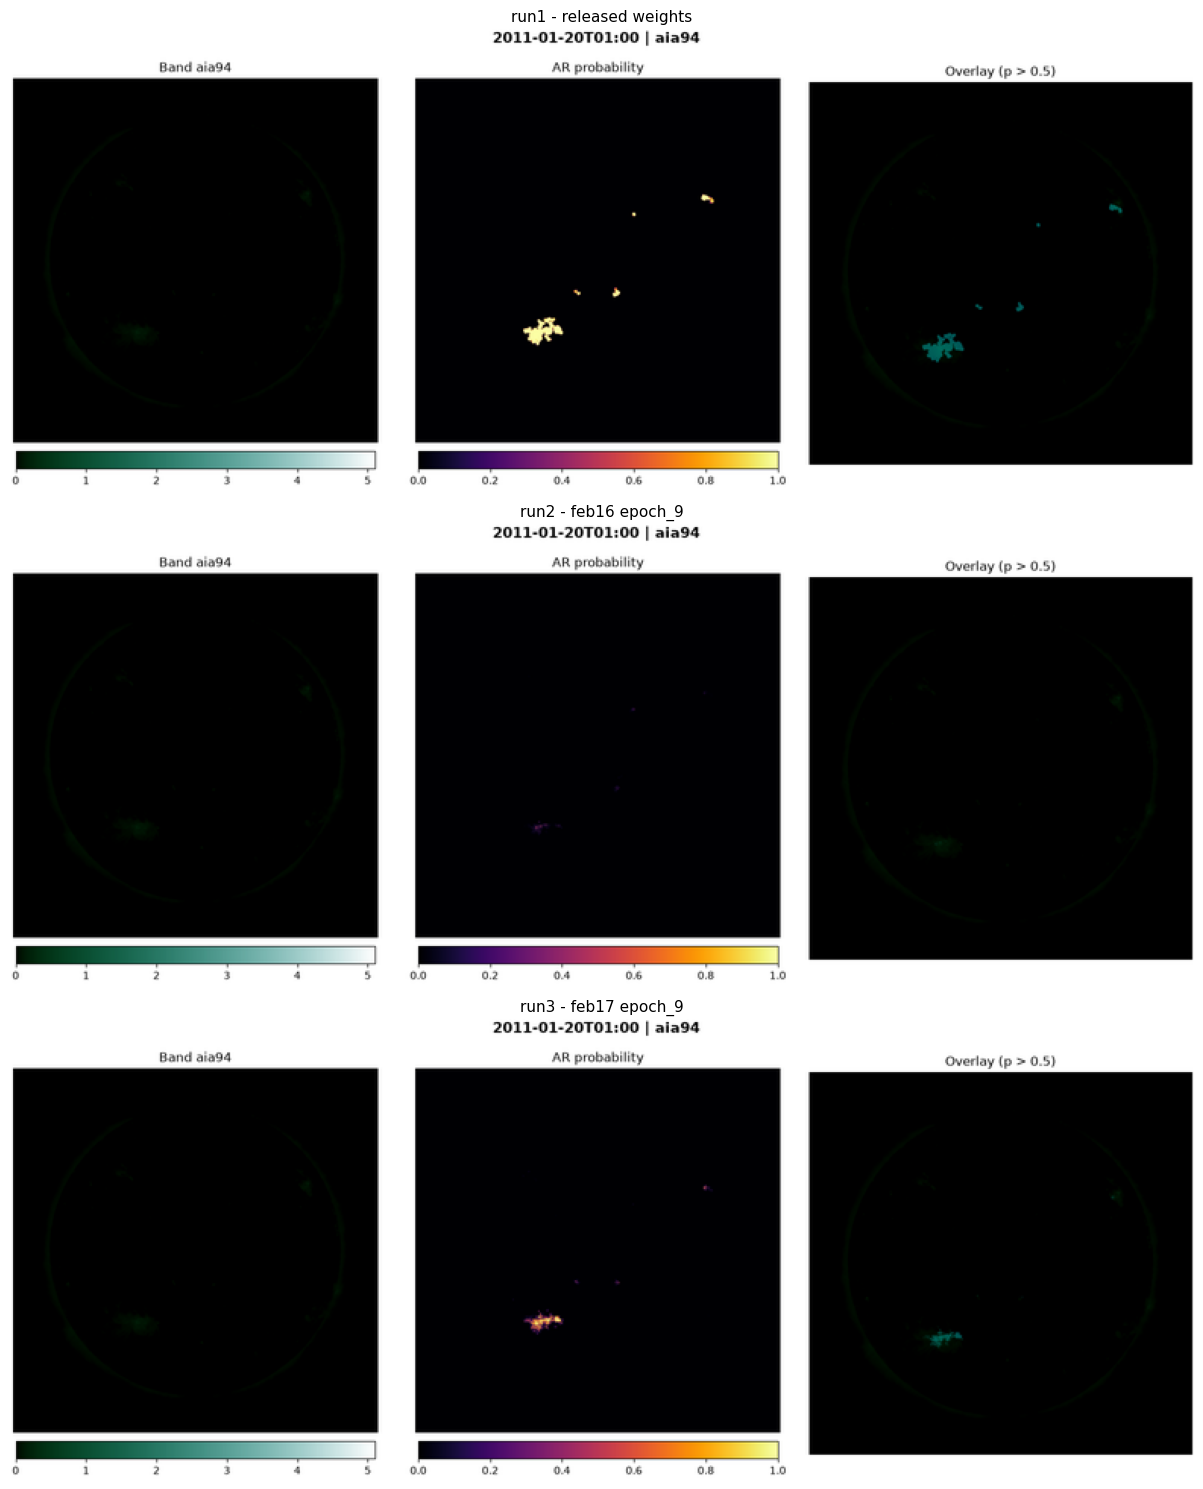

In [3]:
show(
    [(label, find(d, f"*_{CHANNEL}.png")) for label, d in RUN_DIRS.items()],
    ncols=1,
    height=5,
)

## 2. Pixelwise mean across the runs

Left is the mean mask, right is that agreement overlaid on the channel image.
A pixel's value is the fraction of runs that called it active region.

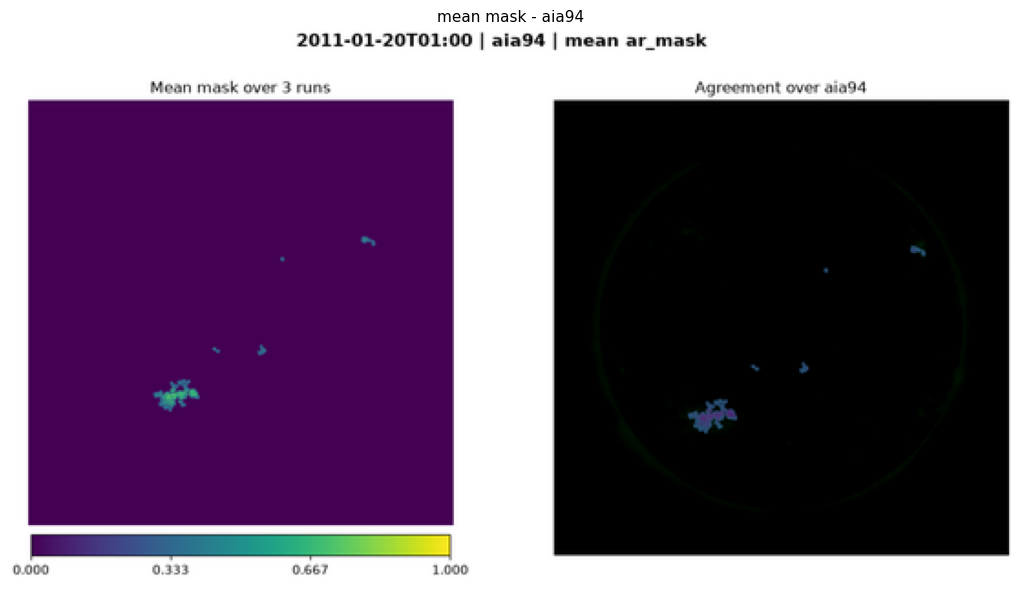

In [4]:
show([(f"mean mask - {CHANNEL}", find(MEAN_DIR, f"*_{CHANNEL}_mask_mean.png"))], height=6)

In [5]:
path = find(MEAN_DIR, f"*_{CHANNEL}_mask_mean.nc")
if path:
    with xr.open_dataset(path, engine="h5netcdf") as ds:
        mean = ds.mask_mean.values
        n_runs = ds.attrs["n_runs"]
        print(f"{ds.attrs['data_time']}  |  {ds.attrs['averaged_variable']} over {n_runs} runs")
        print(f"runs: {ds.attrs['runs']}\n")

    print(f"{'agreement':<18}{'pixels':>12}{'% of frame':>14}")
    for k in range(n_runs + 1):
        level = k / n_runs
        count = int(np.isclose(mean, level).sum())
        label = "none" if k == 0 else f"{k} of {n_runs} runs"
        print(f"{label:<18}{count:>12,}{100 * count / mean.size:>13.4f}%")

2011-01-20T01:00  |  ar_mask over 3 runs
runs: /home/jovyan/infer_run1; /home/jovyan/infer_run2; /home/jovyan/infer_run3

agreement               pixels    % of frame
none                16,699,118      99.5345%
1 of 3 runs             57,391       0.3421%
2 of 3 runs             20,250       0.1207%
3 of 3 runs                457       0.0027%


## 3. False-colour render

Single-hue sequential ramp — lighter means more runs agreed. The ramp was
checked with the data-viz palette validator against a dark surface
(`#1c5cab,#3987e5,#b7d3f6 --mode dark --ordinal`).

Full frame first, then a zoom onto the region of highest agreement.

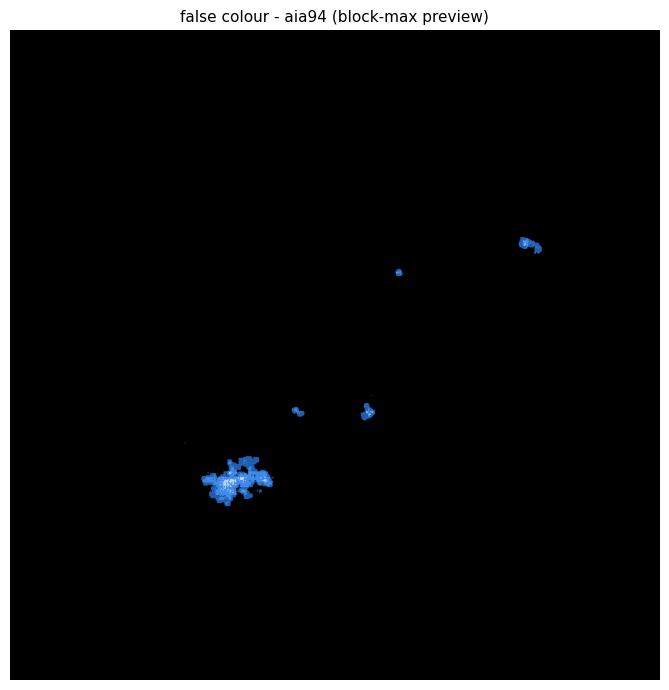

In [6]:
fc = find(FALSE_COLOR_DIR, f"*_{CHANNEL}_*false_color.jpg") or find(FALSE_COLOR_DIR, "*false_color.jpg")
show([(f"false colour - {CHANNEL} (block-max preview)", fc)], height=7, sparse=True)

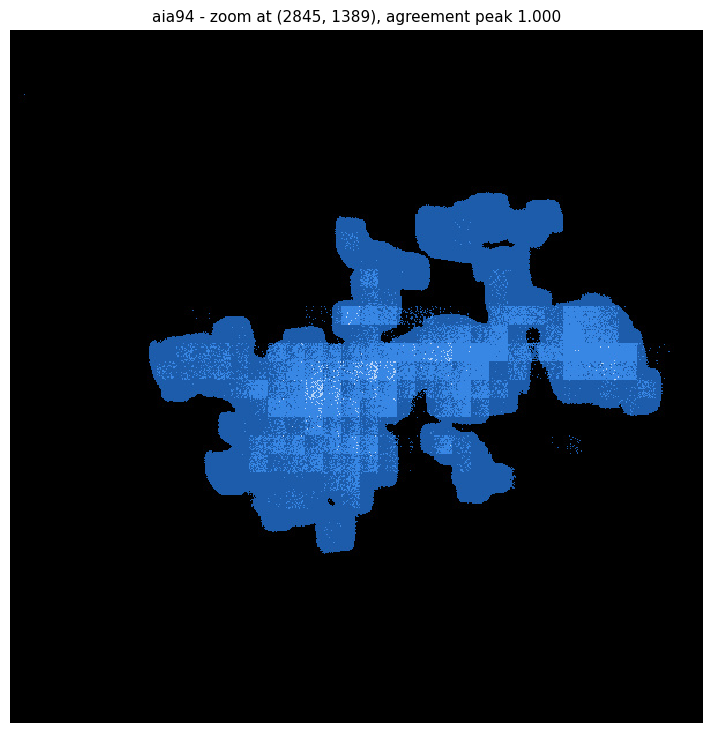

Blocky edges are real: the disagreement follows the model's 16-pixel patch grid.


In [7]:
if fc and path:
    # Centre the zoom on the highest agreement level present.
    top = max(v for v in np.unique(mean) if v > 0) if (mean > 0).any() else 0
    ys, xs = np.nonzero(np.isclose(mean, top))
    cy, cx = int(np.median(ys)), int(np.median(xs))
    half = 300
    y0, x0 = max(0, cy - half), max(0, cx - half)

    img = np.asarray(Image.open(fc))[y0:y0 + 2 * half, x0:x0 + 2 * half]
    plt.figure(figsize=(9, 9))
    plt.imshow(img, interpolation="nearest")
    plt.title(f"{CHANNEL} - zoom at ({cy}, {cx}), agreement peak {top:.3f}", fontsize=11)
    plt.axis("off")
    plt.show()
    print("Blocky edges are real: the disagreement follows the model's 16-pixel patch grid.")

## 4. Browse any channel

Pick a channel to redraw sections 1-3 without editing the constant above.

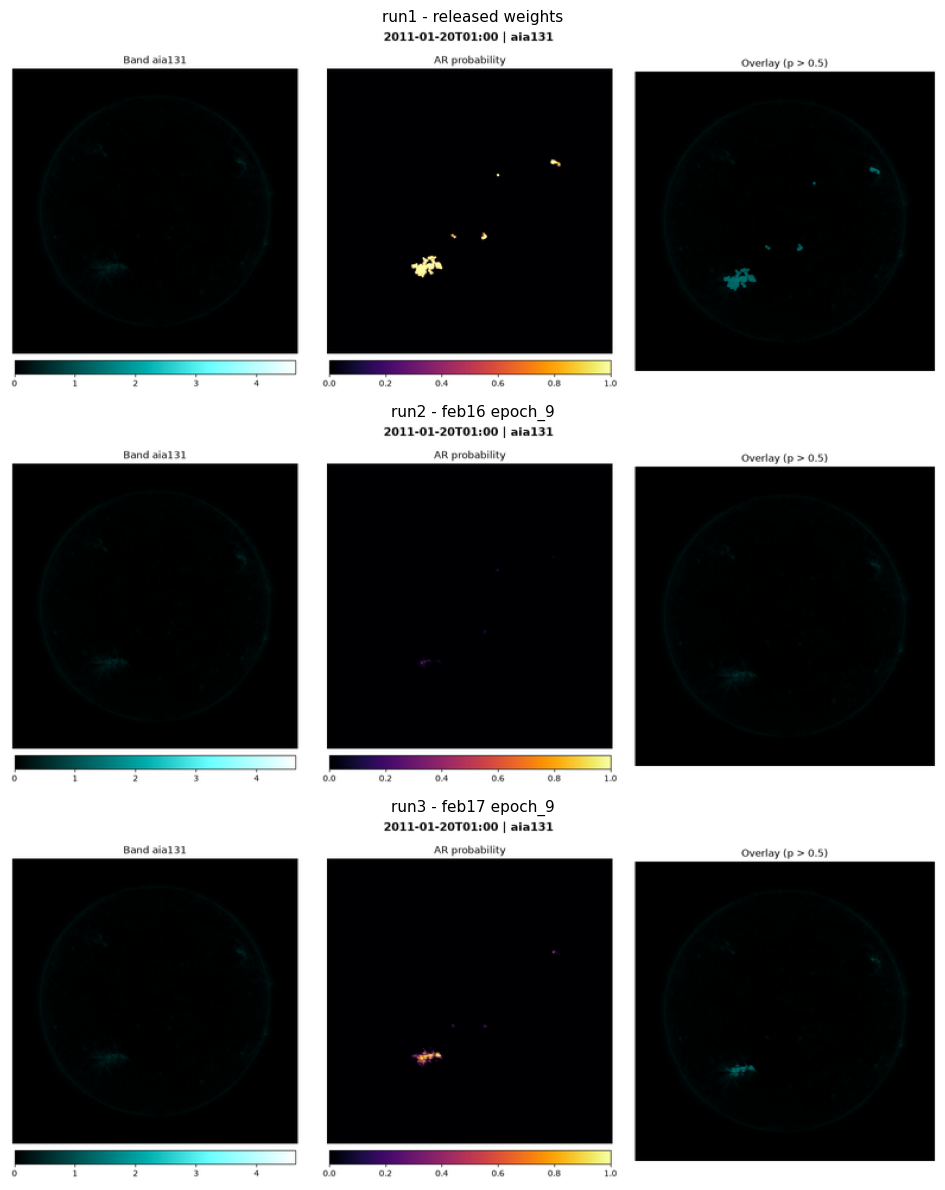

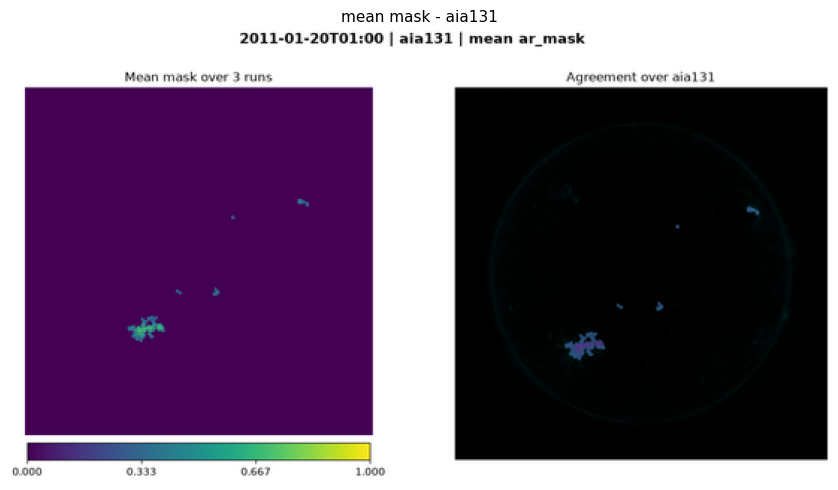

interactive(children=(Dropdown(description='channel', options=('aia131', 'aia1600', 'aia171', 'aia193', 'aia21…

In [8]:
import ipywidgets as widgets
from IPython.display import display

channels = sorted(
    os.path.basename(p).split("_")[-3]
    for p in glob.glob(os.path.join(expand(MEAN_DIR), "*_mask_mean.nc"))
)


def redraw(channel):
    show([(label, find(d, f"*_{channel}.png")) for label, d in RUN_DIRS.items()], height=4)
    show([(f"mean mask - {channel}", find(MEAN_DIR, f"*_{channel}_mask_mean.png"))], height=5)


if channels:
    widgets.interact(redraw, channel=widgets.Dropdown(options=channels, value=channels[0]))
else:
    print("No averaged files found; run average_masks.py first.")